<a href="https://colab.research.google.com/github/mollybocock/AI-Assignment-1/blob/main/xai_in_llms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction and Data Source

For this assigment I decided to comparae the most popular boy's and girl's baby names by red and blue states. I was intrigued if the names would differ the most by political state or by gender. This data gives insight into two prominent divides currently in American society - of political affiliation (or red and blue states) and male/female. Source for the data: https://nameberry.com/blog/the-reddest-and-bluest-baby-names

#Findings

What's most apparent is that both influencing factors (gender and political/regional differences) show less extreme separation in 2023 compared to 1994: the centroid distances in the embedding space are ~10x smaller in 2023 than in 1994. As an example, the distance between blue_boy and red_boy decreased from 2.1202 (1994) to 0.2982 (2023). This means that in terms of naming patterns, the groups are closer together mathematically. Parents in different regions (red vs. blue states) are now more likely to choose similar names for their children than they were in 1994, although there are similar regional differences and strong gender differences as there were in 1994.

In both sets of data, gender and political affiliation had similar influence on baby names in 1994 as in 2023. However, there is more convergence in the 2023 data - there is more intermixing of names in 2023 than in 1994. The data and the patterns suggest that baby naming patters in America have become more homogenous over the 30 years period.  This is particularly interesting because by Pew’s measuring standards the United States is more polarized in 2023 than in 1994, so one conclusion could be that as baby names grow closer together and intermix across gender and political state, polarization increases
#Generated with help from Claude 3.7 Sonnet

#[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mollybocock/AI-Assignment-1/blob/main/XAI_In_LLMs.ipynb)


#Install Neccessary Libraries

In [ ]:
!pip install -q sentence-transformers transformers torch
#Source:@article{wang2024multilingual,
  #title={Multilingual E5 Text Embeddings: A Technical Report},
 #author={Wang, Liang and Yang, Nan and Huang, Xiaolong and Yang, Linjun and Majumder, Rangan and Wei, Furu},
  #journal={arXiv preprint arXiv:2402.05672},
  #year={2024}
#}

#Load the Model from MTEB Leaderboard

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("intfloat/multilingual-e5-small")

# Example sentences
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium."
]

# Encode the sentences
embeddings = model.encode(sentences)

# Compute similarities
similarities = embeddings @ embeddings.T  # Manual cosine similarity
print(similarities.shape)  # Should print (3, 3)
#Source: @article{wang2024multilingual,
  #title={Multilingual E5 Text Embeddings: A Technical Report},
  #author={Wang, Liang and Yang, Nan and Huang, Xiaolong and Yang, Linjun and Majumder, Rangan and Wei, Furu},
  #journal={arXiv preprint arXiv:2402.05672},
  #year={2024}
#}

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

(3, 3)


#PCA, t-SNE and UMAP 2023

Loading model and generating embeddings...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Generated embeddings with shape: (100, 384)
Performing PCA...
Performing t-SNE...
Performing UMAP...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


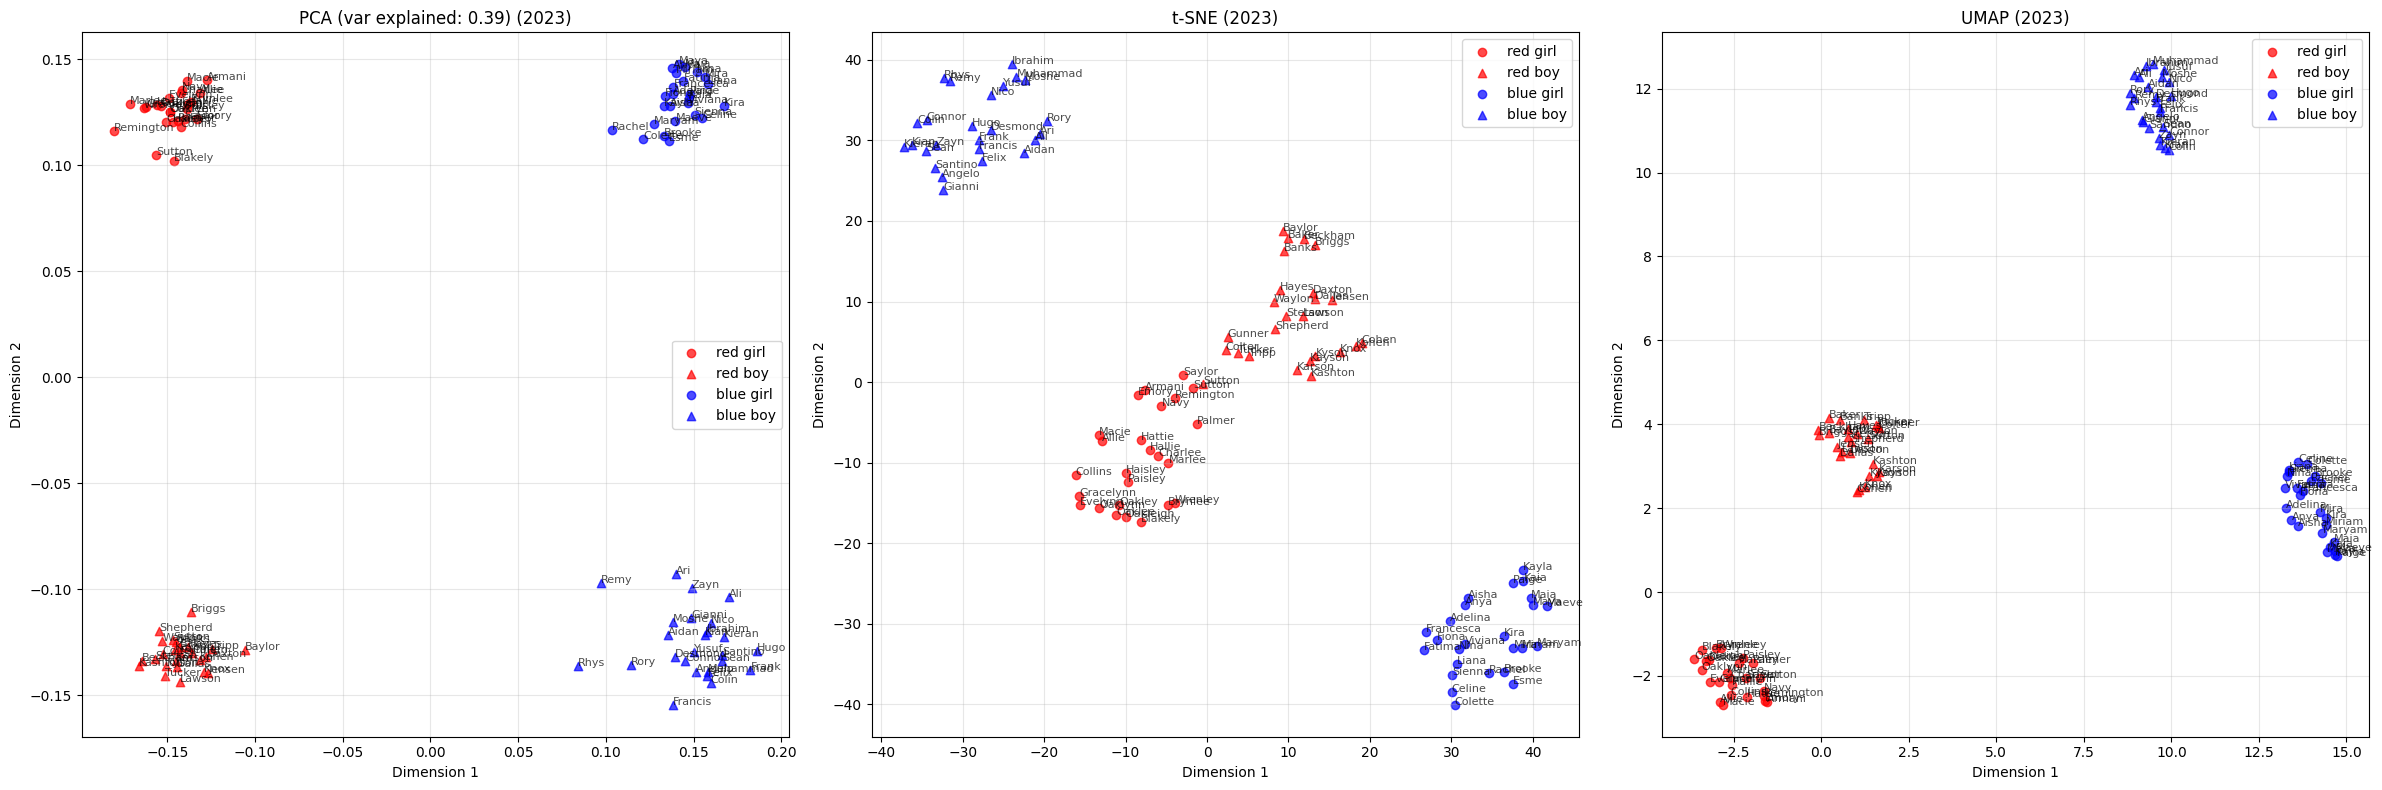


Centroid distances in original embedding space:
Distance between red_boy and red_girl: 0.2640
Distance between blue_girl and red_girl: 0.2955
Distance between blue_girl and red_boy: 0.3861
Distance between blue_boy and red_girl: 0.3884
Distance between blue_boy and red_boy: 0.2982
Distance between blue_boy and blue_girl: 0.2643

Comparison of dimensionality reduction methods:

PCA:
- Explained variance: [0.2183563  0.16994616]
- Total explained variance: 0.3883
- Strengths: Preserves global structure, interpretable components
- Weaknesses: Linear method, may miss non-linear relationships

t-SNE:
- Strengths: Preserves local structure, good at revealing clusters
- Weaknesses: Stochastic results, sensitive to hyperparameters (perplexity)
- Note: Does not preserve global distances

UMAP:
- Strengths: Preserves both local and global structure, faster than t-SNE
- Weaknesses: Sensitive to hyperparameters (n_neighbors, min_dist)
- Note: Generally better at preserving global structure than t

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create structured dataframes from the baby names data
def create_dataframes():
    blue_girls = pd.DataFrame({
        'name': ['Fiona', 'Liana', 'Mira', 'Maryam', 'Kira', 'Miriam', 'Nina', 'Aisha', 'Paige', 'Kayla',
                 'Brooke', 'Rachel', 'Celine', 'Adelina', 'Francesca', 'Maia', 'Maya', 'Viviana', 'Esme',
                 'Fatima', 'Kaia', 'Colette', 'Anya', 'Maeve', 'Sienna'],
        'percentage': [77.7, 74.8, 74.6, 74.5, 74.4, 73.5, 71.8, 71.2, 70.9, 70.7,
                       70.5, 70.5, 70.3, 69.9, 69.6, 69.6, 69.3, 69.3, 68.6,
                       68.6, 68.2, 68.2, 68.0, 67.9, 67.8],
        'gender': 'girl',
        'political': 'blue'
    })

    blue_boys = pd.DataFrame({
        'name': ['Moshe', 'Santino', 'Muhammad', 'Yusuf', 'Kieran', 'Ari', 'Aidan', 'Ibrahim', 'Ali', 'Nico',
                 'Colin', 'Francis', 'Angelo', 'Remy', 'Desmond', 'Felix', 'Frank', 'Zayn', 'Gianni',
                 'Hugo', 'Sean', 'Rhys', 'Rory', 'Kian', 'Connor'],
        'percentage': [97.1, 80.6, 79.2, 78.2, 74.2, 74.1, 74.1, 73.0, 72.5, 72.3,
                       72.0, 71.8, 70.0, 69.6, 68.4, 68.0, 68.0, 67.9, 67.9,
                       67.8, 67.8, 67.8, 67.5, 67.3, 67.0],
        'gender': 'boy',
        'political': 'blue'
    })

    red_girls = pd.DataFrame({
        'name': ['Hattie', 'Oaklynn', 'Oakleigh', 'Gracelynn', 'Wrenley', 'Blakely', 'Collins', 'Oaklee', 'Saylor', 'Oakley',
                 'Palmer', 'Haisley', 'Armani', 'Sutton', 'Marlee', 'Charlee', 'Brynlee', 'Remington', 'Hallie',
                 'Evelynn', 'Paisley', 'Navy', 'Emory', 'Macie', 'Allie'],
        'percentage': [65.6, 64.5, 64.3, 63.1, 63.1, 62.3, 62.1, 62.0, 60.6, 60.4,
                       60.0, 59.0, 58.5, 58.5, 58.4, 58.4, 58.2, 58.1, 58.0,
                       57.4, 56.4, 56.1, 56.0, 55.4, 55.3],
        'gender': 'girl',
        'political': 'red'
    })

    red_boys = pd.DataFrame({
        'name': ['Kohen', 'Baylor', 'Stetson', 'Kyson', 'Tripp', 'Sutton', 'Briggs', 'Cohen', 'Gunner', 'Baker',
                 'Jensen', 'Lawson', 'Hayes', 'Colter', 'Waylon', 'Shepherd', 'Banks', 'Karson', 'Kayson',
                 'Beckham', 'Knox', 'Daxton', 'Tucker', 'Kashton', 'Dallas'],
        'percentage': [71.5, 71.2, 69.0, 65.9, 65.5, 64.3, 62.3, 61.5, 61.3, 61.3,
                       60.9, 60.7, 60.0, 59.7, 59.4, 59.0, 58.9, 58.3, 58.3,
                       58.2, 58.2, 57.8, 57.6, 57.4, 57.3],
        'gender': 'boy',
        'political': 'red'
    })

    # Combine into one dataframe
    df = pd.concat([blue_girls, blue_boys, red_girls, red_boys])
    return df

# Load data
df = create_dataframes()

# Format names with prefixes to provide context for the embedding model
def format_names(df):
    # Create formatted texts that provide context
    df['formatted_name'] = df.apply(
        lambda row: f"{row['political']} state {row['gender']} name: {row['name']}",
        axis=1
    )
    return df

df = format_names(df)

# Generate embeddings using the E5 model
print("Loading model and generating embeddings...")
model = SentenceTransformer('intfloat/multilingual-e5-small')
embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)
print(f"Generated embeddings with shape: {embeddings.shape}")

# Create color and marker mappings for visualization
color_map = {'red': 'red', 'blue': 'blue'}
marker_map = {'girl': 'o', 'boy': '^'}

# Function to create scatter plot
def create_scatter_plot(df, x, y, title, ax):
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            ax.scatter(
                x[mask], y[mask],
                c=color_map[political],
                marker=marker_map[gender],
                alpha=0.7,
                label=f"{political} {gender}"
            )

    # Add labels
    for i, name in enumerate(df['name']):
        ax.annotate(name, (x[i], y[i]), fontsize=8, alpha=0.7)

    ax.set_title(f"{title} (2023)")
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.grid(alpha=0.3)
    ax.legend()

# Perform dimensionality reduction
def perform_dim_reduction():
    # Set up the plot
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # 1. PCA
    print("Performing PCA...")
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)
    create_scatter_plot(df, pca_result[:, 0], pca_result[:, 1],
                        f'PCA (var explained: {sum(pca.explained_variance_ratio_):.2f})', axes[0])

    # 2. t-SNE
    print("Performing t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    tsne_result = tsne.fit_transform(embeddings)
    create_scatter_plot(df, tsne_result[:, 0], tsne_result[:, 1], 't-SNE', axes[1])

    # 3. UMAP
    print("Performing UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42,
                            n_neighbors=5, min_dist=0.1)
    umap_result = umap_reducer.fit_transform(embeddings)
    create_scatter_plot(df, umap_result[:, 0], umap_result[:, 1], 'UMAP', axes[2])

    plt.tight_layout()
    return fig, pca, tsne, umap_reducer, pca_result, tsne_result, umap_result

# Run the analysis
fig, pca, tsne, umap_reducer, pca_result, tsne_result, umap_result = perform_dim_reduction()

# Save the figure
plt.savefig('embedding_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional analysis: Calculate centroids for each group
def calculate_centroids():
    centroids = {}
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            centroids[f"{political}_{gender}"] = np.mean(embeddings[mask], axis=0)

    # Calculate distances between centroids
    print("\nCentroid distances in original embedding space:")
    for key1 in centroids:
        for key2 in centroids:
            if key1 < key2:  # Avoid duplicates
                dist = np.linalg.norm(centroids[key1] - centroids[key2])
                print(f"Distance between {key1} and {key2}: {dist:.4f}")

    return centroids

# Compare the dimensionality reduction methods
def compare_methods():
    print("\nComparison of dimensionality reduction methods:")

    print("\nPCA:")
    print(f"- Explained variance: {pca.explained_variance_ratio_}")
    print(f"- Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")
    print("- Strengths: Preserves global structure, interpretable components")
    print("- Weaknesses: Linear method, may miss non-linear relationships")

    print("\nt-SNE:")
    print("- Strengths: Preserves local structure, good at revealing clusters")
    print("- Weaknesses: Stochastic results, sensitive to hyperparameters (perplexity)")
    print("- Note: Does not preserve global distances")

    print("\nUMAP:")
    print("- Strengths: Preserves both local and global structure, faster than t-SNE")
    print("- Weaknesses: Sensitive to hyperparameters (n_neighbors, min_dist)")
    print("- Note: Generally better at preserving global structure than t-SNE")

    # Calculate silhouette scores for each projection to evaluate cluster separation
    from sklearn.metrics import silhouette_score

    labels = pd.Categorical(df['political'] + '_' + df['gender']).codes

    try:
        pca_silhouette = silhouette_score(pca_result, labels)
        tsne_silhouette = silhouette_score(tsne_result, labels)
        umap_silhouette = silhouette_score(umap_result, labels)

        print("\nCluster separation quality (silhouette score, higher is better):")
        print(f"- PCA: {pca_silhouette:.4f}")
        print(f"- t-SNE: {tsne_silhouette:.4f}")
        print(f"- UMAP: {umap_silhouette:.4f}")
    except:
        print("Could not calculate silhouette scores")

# Run additional analyses
centroids = calculate_centroids()
compare_methods()

#Source: Generated with Claude Sonnet 3.7 03/26/2025 13:26
#Source: https://claude.site/artifacts/6324fa7a-4195-4d96-b153-f39fea6f7dd3

#Compare and Contrasting Results and Summary of Results

The PCA shows the data relegated to four distinct clusters. It looks like Dimension 1 separates the red and the blue states and Dimension 2 separates the boy and girl names. Claude found that the primary dimensions explain about 39% of the variance (21.8% and 17%). Each of the visualization methods show four clusters, but it UMAP creates the most visually distinct groups while t-SNE does a better job showing the inter relationships inside of the clusters.

The t-SNE shows that there are actually smaller sub-clusters at play here too. We get a line of red names through the center and then large clusters of blue at either diagonal corner. According to Claude, in the t-SNE the relative positions of clusters are less meaningful than in PCA however, the t-SNE preserves local neighborhood relationships better.

UMAP has distinct clusters that are tight together, its very difficult to read the individual names because they overlap with each other. The compactness of the clusters indicates that there are strong similarities within each group.

Looking at the centroid differences in the original embedding space, gender differences (red_boy to red_girl: 0.2640, blue_boy to blue_girl: 0.2643) are  similar to political differences within the same gender (blue_boy to red_boy: 0.2982, blue_girl to red_girl: 0.2955). Therefore, gender and politcal differences have around the same influence on baby names.

Generated with help from Claude 3.7 Sonnet



#t-SNE Visualization in 3D 2023

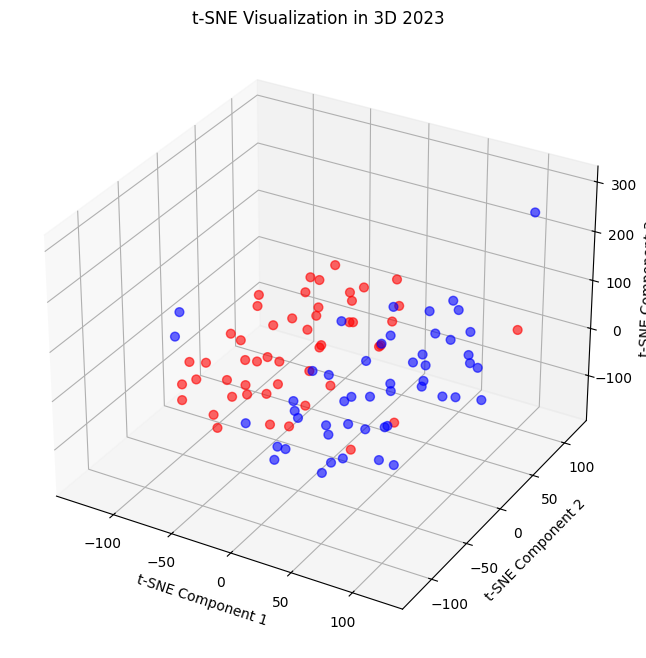

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting tools

# Perform t-SNE for 3 components (3D)
tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Color points by their 'political' and 'gender' labels, assuming they are in the 'df' dataframe
color_map = {'red': 'r', 'blue': 'b'}
c = df['political'].apply(lambda x: color_map[x])

# Scatter plot of t-SNE results (x, y, z)
ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], c=c, s=40, alpha=0.6)

# Labels for axes
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')

# Title of the plot
plt.title("t-SNE Visualization in 3D 2023")

# Display the plot
plt.show()
#Source: CLaude Sonnet 3.7 03/26-2025 14:30

#3D Visualization 2023 data with Names

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


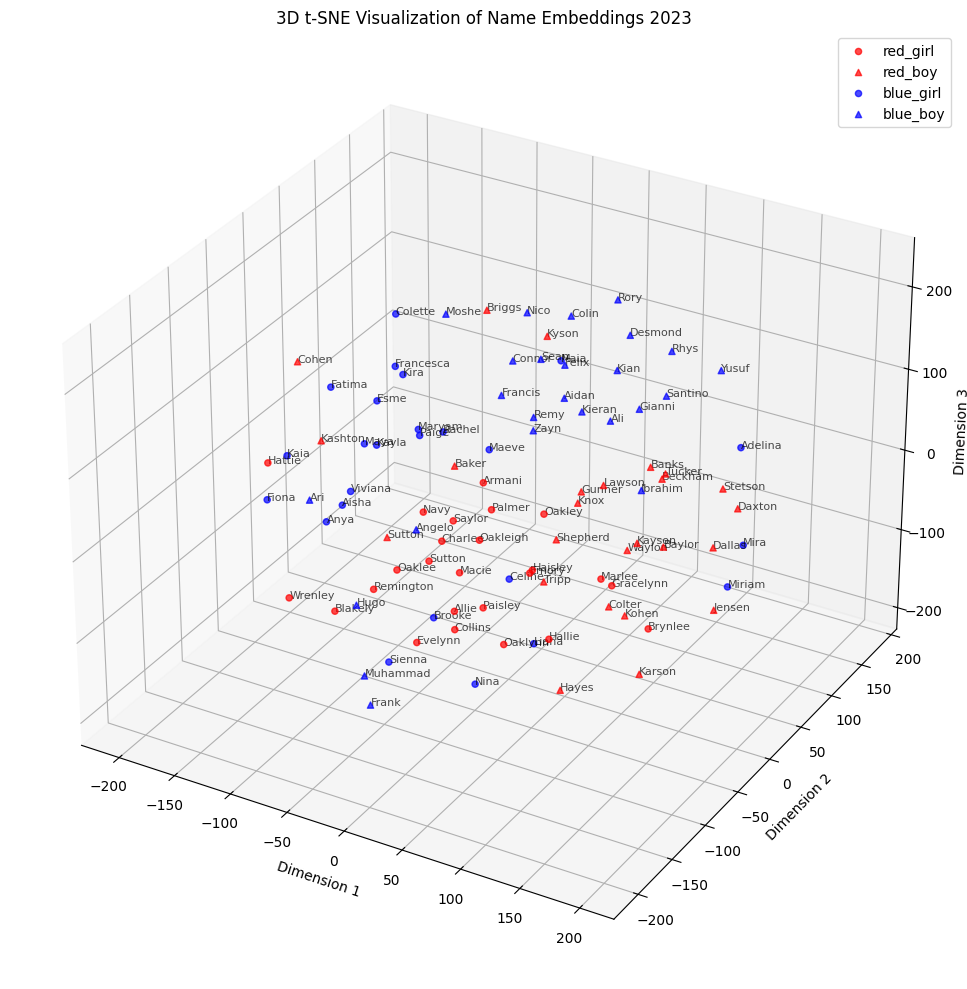

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

# Assuming df and embeddings are already created as shown in your code
# embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)

# Configure t-SNE for 3D output
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

# Use the embeddings directly, not the dataframe
trans_data = tsne.fit_transform(embeddings)

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Get indices for each category
color_map = {'red': 'r', 'blue': 'b'}
marker_map = {'girl': 'o', 'boy': '^'}

# Plot each category with its color and marker
for political in ['red', 'blue']:
    for gender in ['girl', 'boy']:
        # Filter indices matching this combination
        mask = (df['political'] == political) & (df['gender'] == gender)
        indices = np.where(mask)[0]

        # Plot this group
        ax.scatter(
            trans_data[indices, 0],
            trans_data[indices, 1],
            trans_data[indices, 2],
            c=color_map[political],
            marker=marker_map[gender],
            label=f"{political}_{gender}",
            alpha=0.7
        )

# Add labels and annotations
for i, name in enumerate(df['name']):
    ax.text(trans_data[i, 0], trans_data[i, 1], trans_data[i, 2], name, fontsize=8, alpha=0.7)

# Set axis labels and title
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.set_title('3D t-SNE Visualization of Name Embeddings 2023')
ax.legend()

plt.tight_layout()
plt.show()

#Analyze 3d 2023 data
The gender boundary appears to be the most defined. This data would suggest that gender associations in names are more influential than political associations in the name embeddings. There appears to be a bit more intermingling of names than in 1994 data.

#Adding Another Datset to Compare: 1994

I thought this data was really interesting, especially with the insight it gives that political factors appear to be more influential for determining names rather than gender. I wanted to compare these results to another time in American history where there was noticeably less polarization to see if in the past there was perhaphs a larger gender gap but smaller political gap or if the boys and girls names in red and blue states were closer to each other in the embedding space. I chose the year 1994, because in 1994 the Pew Center for Research found there was a much smaller ideological divide than in 2004 or even 2014. Source: https://www.pewresearch.org/politics/2014/06/12/political-polarization-in-the-american-public/

This dataset is not perfect; I took it from the list of popular names by state proivided by the Social Security Online website, however, I only took the top 40 or so names for boys and girls in each red and blue state. Whereas the red and blue state baby names for 2023 from Nameberry gives a percentage. For example, if "Fion" is the top girl baby name in a blue state, Nameberry also provides the statistic 77.7% Blue, meaning that 77.7% of American baby girls named Fiona in the US in 2023 were born in Blue States. Due to time and resource limitations, I could not recreate the dataset from 1994 exactly as the one from 2023 but decided that the data I could use would provide interesting insight.  
#Source: https://www.ssa.gov/cgi-bin/namesbystate.cgi

#1994 Baby Names Girls and Boys by Red States and Blue t-SNE 3D visualization with Centroid Calculations

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Centroid distances in original embedding space:
Distance between red_girl and red_boy: 1.9897
Distance between red_girl and blue_girl: 2.1049
Distance between red_girl and blue_boy: 2.8614
Distance between red_boy and red_girl: 1.9897
Distance between red_boy and blue_girl: 2.9550
Distance between red_boy and blue_boy: 2.1202
Distance between blue_girl and red_girl: 2.1049
Distance between blue_girl and red_boy: 2.9550
Distance between blue_girl and blue_boy: 2.1350
Distance between blue_boy and red_girl: 2.8614
Distance between blue_boy and red_boy: 2.1202
Distance between blue_boy and blue_girl: 2.1350


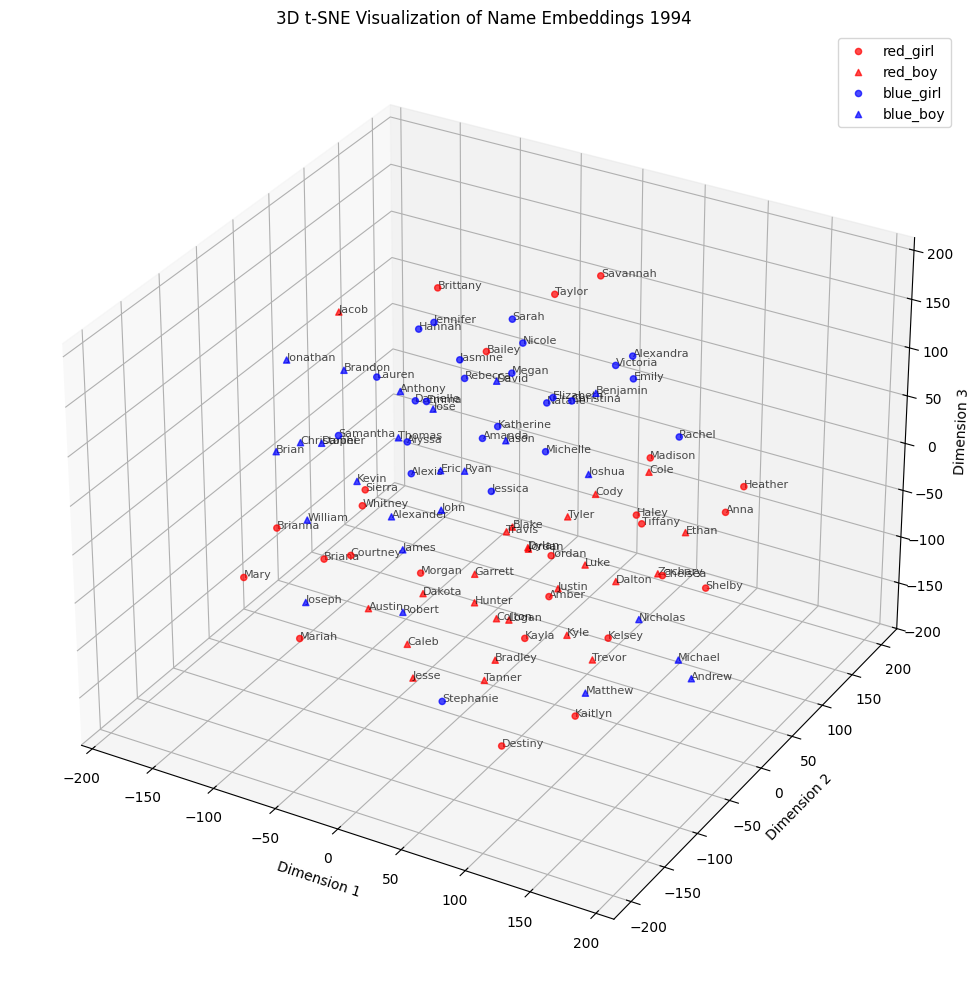

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

# Assuming df and embeddings are already created as shown in your code
# embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)

# Configure t-SNE for 3D output
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

# Use the embeddings directly, not the dataframe
trans_data = tsne.fit_transform(embeddings)

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Get indices for each category
color_map = {'red': 'r', 'blue': 'b'}
marker_map = {'girl': 'o', 'boy': '^'}

# Plot each category with its color and marker
for political in ['red', 'blue']:
    for gender in ['girl', 'boy']:
        # Filter indices matching this combination
        mask = (df['political'] == political) & (df['gender'] == gender)
        indices = np.where(mask)[0]

        # Plot this group
        ax.scatter(
            trans_data[indices, 0],
            trans_data[indices, 1],
            trans_data[indices, 2],
            c=color_map[political],
            marker=marker_map[gender],
            label=f"{political}_{gender}",
            alpha=0.7
        )

# Add labels and annotations
for i, name in enumerate(df['name']):
    ax.text(trans_data[i, 0], trans_data[i, 1], trans_data[i, 2], name, fontsize=8, alpha=0.7)

# Set axis labels and title
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.set_title('3D t-SNE Visualization of Name Embeddings 1994')
ax.legend()


#########################
# ADDITIONAL ANALYSIS
#########################

# Calculate centroids for each group
def calculate_centroids():
    centroids = {}
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            centroids[f"{political}_{gender}"] = np.mean(embeddings[mask], axis=0)
    return centroids

# Calculate distances between centroids
def calculate_distances(centroids):
    print("Centroid distances in original embedding space:")
    for key1 in centroids:
        for key2 in centroids:
            if key1 != key2:
                dist = np.linalg.norm(centroids[key1] - centroids[key2])
                print(f"Distance between {key1} and {key2}: {dist:.4f}")

# Run additional analysis
centroids = calculate_centroids()
calculate_distances(centroids)

# Find outliers by calculating distances to group centroids
def find_outliers():
    outliers = []
    for i, name in enumerate(df['name']):
        political = df.iloc[i]['political']
        gender = df.iloc[i]['gender']
        group_key = f"{political}_{gender}"

        # Calculate distance to own centroid
        own_dist = np.linalg.norm(embeddings[i] - centroids[group_key])

        # Find distances to all centroids
        all_dists = {}
        for key in centroids:
            all_dists[key] = np.linalg.norm(embeddings[i] - centroids[key])

        # Check if it's an outlier (far from its own centroid)
        if own_dist > 1.5 * np.mean([all_dists[k] for k in all_dists]):
            outliers.append({
                'name': name,
                'group': group_key,
                'distance_to_own_centroid': own_dist,
                'distances_to_centroids': all_dists
            })

    # Print outliers information
    if outliers:
        print("\nPotential outliers:")
        for outlier in outliers:
            print(f"Name: {outlier['name']} (Group: {outlier['group']})")
            print(f"  Distance to own centroid: {outlier['distance_to_own_centroid']:.4f}")
            print("  Distances to all centroids:")
            for k, v in outlier['distances_to_centroids'].items():
                print(f"    {k}: {v:.4f}")
            print()

# Find potential outliers
find_outliers()

plt.tight_layout()
plt.show()
#Source: Calude Sonnet 3.6 14:35

The distances are noticeably larger than in the 2023 data, which indicates that naming patterns had more pronounced regional and gender differences in 1994 than in 2023. Both gender and poltical differences had similar influences on baby names. Interestingly, the distance between red_girl and red_boy: 1.9897
and the distance between blue_girl and blue_boy: 2.1350 suggests that gender differences in blue states were slightly more pronounced than in red states.

#1994 Dataset with PCA, t-SNE, and UMAP

In [ ]:
pip install plotly


Source: https://www.pewresearch.org/politics/2014/06/12/political-polarization-in-the-american-public/

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


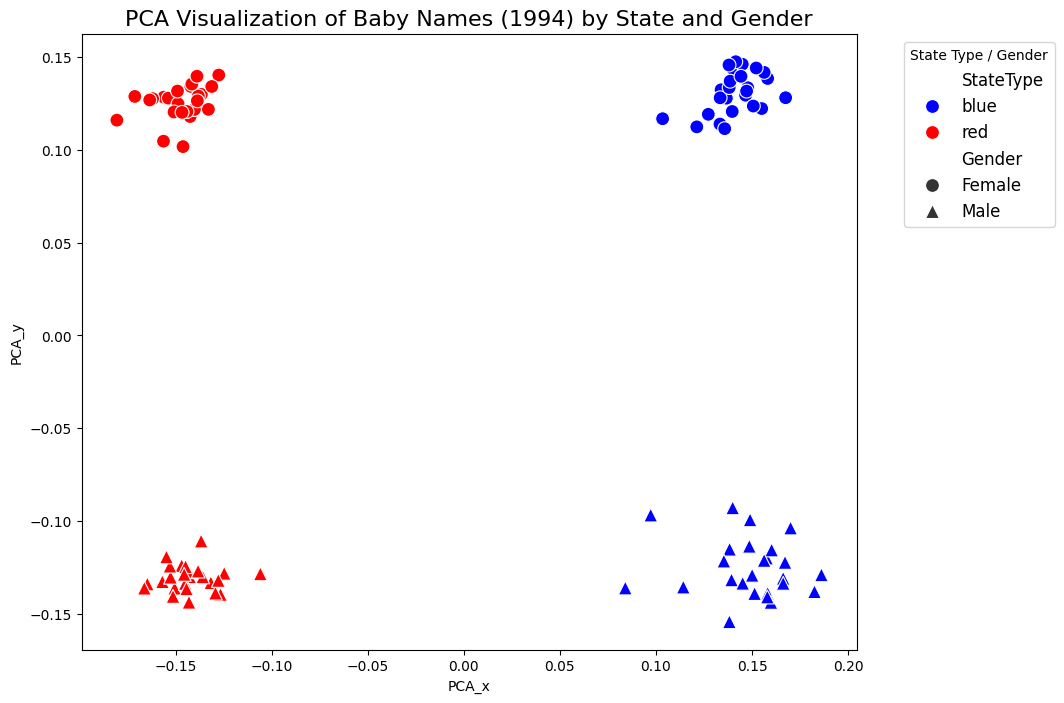

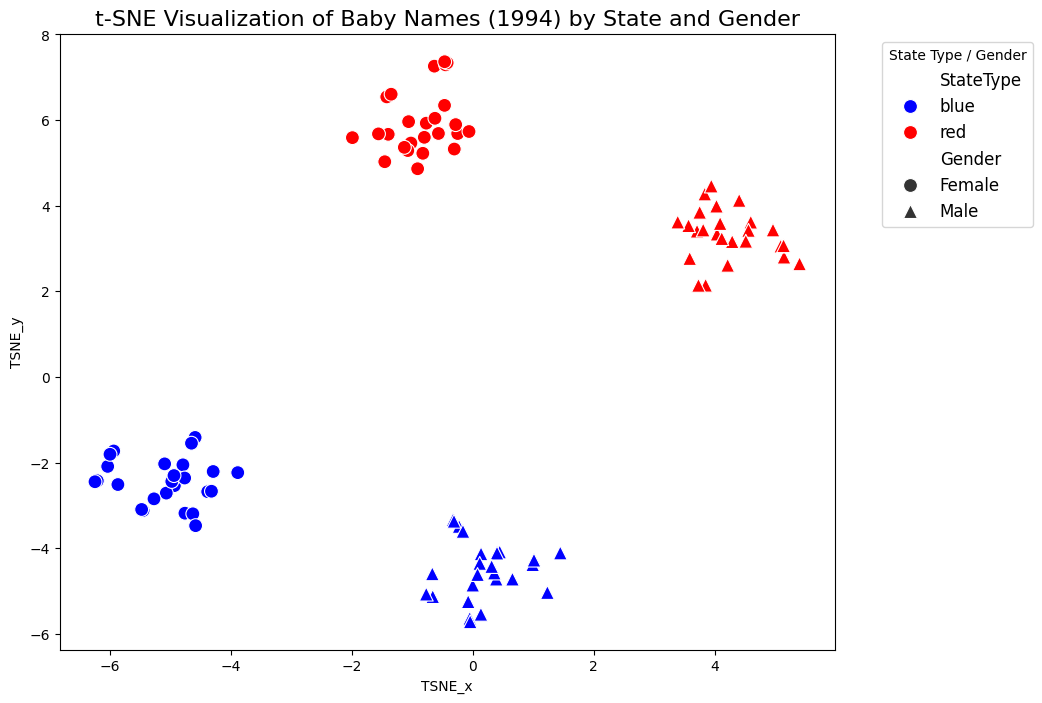

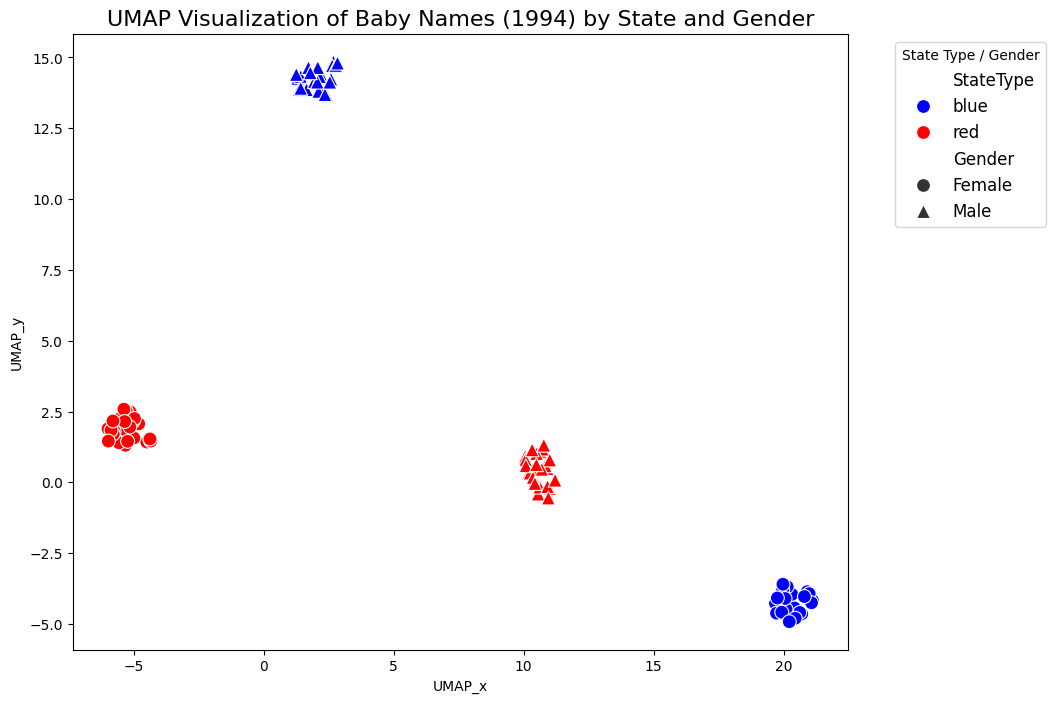

In [ ]:
# Add these lines to ensure proper column assignment
df['StateType'] = df['political']
df['Gender'] = df['gender']

# Replace Gender column values if necessary
df['Gender'] = df['Gender'].replace({'girl': 'Female', 'boy': 'Male'})

# Generate embeddings for the formatted names
embeddings = model.encode(df["formatted_name"].tolist())

# Apply PCA for dimensionality reduction to 10 components (pre-step for t-SNE/UMAP)
pca = PCA(n_components=10, random_state=42)
pca_embeddings = pca.fit_transform(embeddings)

# Apply t-SNE for further dimensionality reduction to 2D
tsne = TSNE(n_components=2, random_state=42)
tsne_embeddings = tsne.fit_transform(pca_embeddings)

# Apply UMAP for further dimensionality reduction to 2D
umap_model = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
umap_embeddings = umap_model.fit_transform(pca_embeddings)

# Add t-SNE and UMAP results to the dataframe for plotting
df["TSNE_x"] = tsne_embeddings[:, 0]
df["TSNE_y"] = tsne_embeddings[:, 1]
df["UMAP_x"] = umap_embeddings[:, 0]
df["UMAP_y"] = umap_embeddings[:, 1]

# Apply PCA for dimensionality reduction to 2D (for visualization purposes)
pca_2d = PCA(n_components=2, random_state=42)
pca_2d_embeddings = pca_2d.fit_transform(embeddings)

# Add PCA results to the dataframe for plotting
df["PCA_x"] = pca_2d_embeddings[:, 0]
df["PCA_y"] = pca_2d_embeddings[:, 1]

# Set custom color palette for StateType (Red/Blue) and markers for Gender (Circle for Female, Triangle for Male)
state_palette = {'red': 'red', 'blue': 'blue'}
gender_markers = {'Female': 'o', 'Male': '^'}

# Plotting PCA visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x="PCA_x", y="PCA_y", hue="StateType", style="Gender", data=df,
                palette=state_palette, markers=gender_markers, s=100)
plt.title("PCA Visualization of Baby Names (1994) by State and Gender", fontsize=16)
plt.legend(title='State Type / Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show()

# Plotting t-SNE visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x="TSNE_x", y="TSNE_y", hue="StateType", style="Gender", data=df,
                palette=state_palette, markers=gender_markers, s=100)
plt.title("t-SNE Visualization of Baby Names (1994) by State and Gender", fontsize=16)
plt.legend(title='State Type / Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show()

# Plotting UMAP visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x="UMAP_x", y="UMAP_y", hue="StateType", style="Gender", data=df,
                palette=state_palette, markers=gender_markers, s=100)
plt.title("UMAP Visualization of Baby Names (1994) by State and Gender", fontsize=16)
plt.legend(title='State Type / Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show()
#Source: Claude 3.7 Sonnet and Chat GPT


#PCA, t-SNE, and UMAP 1994 Analysis

In the PCA plot, gender creates a vertical separation within each state type (red and blue states). In the t-SNE plot, it appears that state is what is mainly influencing the primary clustering, and gender creates secondary clusstering within the state types. Interestingly, the red male state names make the most distinct cluster. In the UMAP, both factors create tight clusters but state type might be slightly more influential. So overall, state political affiliation seems to have a bit more influence over baby names than gender in 1194 although both are influential.

#3D Baby Names 1994

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


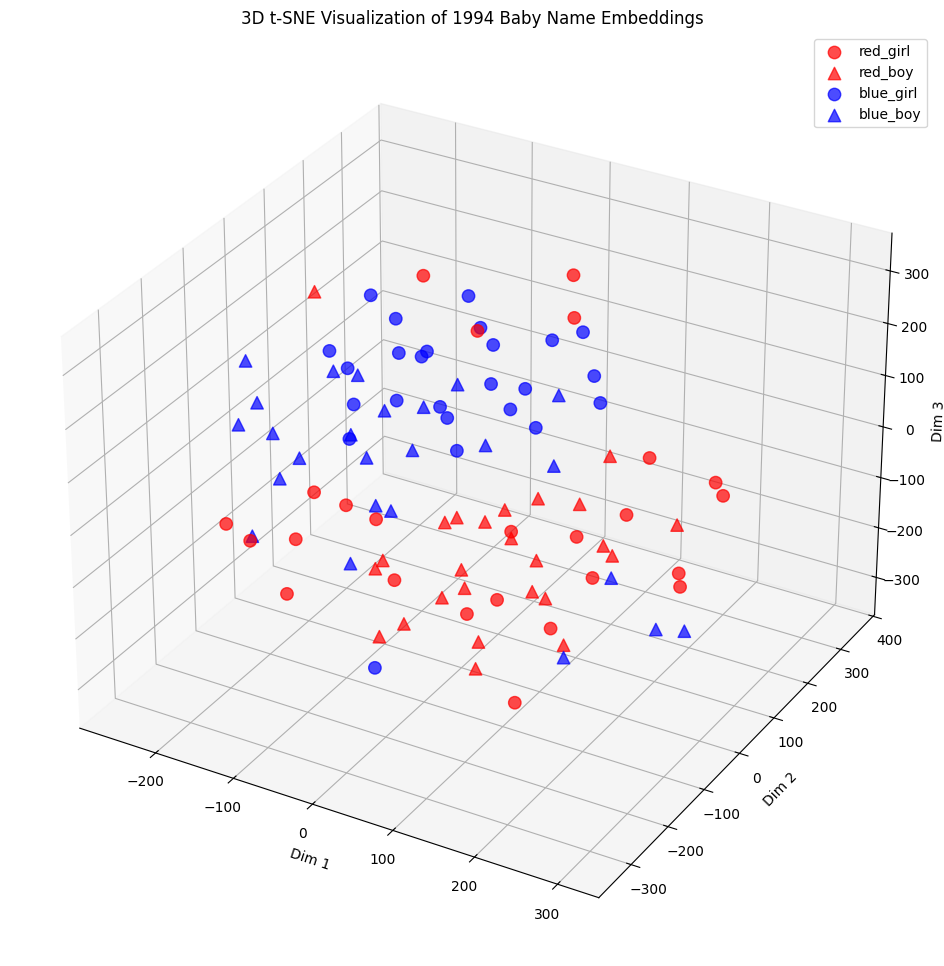

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

#########################
# DATA PREPARATION
#########################

def create_dataframes():
    # Define baby names from 1994 with political affiliations
    red_girls = pd.DataFrame({
        'name': ['Brittany', 'Taylor', 'Kayla', 'Amber', 'Kelsey', 'Morgan', 'Shelby', 'Haley', 'Courtney', 'Tiffany',
                 'Chelsea', 'Brianna', 'Anna', 'Jordan', 'Whitney', 'Madison', 'Savannah', 'Sierra', 'Kaitlyn', 'Mariah',
                 'Mary', 'Destiny', 'Briana', 'Bailey', 'Heather'],
        'percentage': [68.3, 67.9, 66.8, 65.5, 64.7, 64.1, 63.8, 63.5, 62.9, 62.3,
                      61.9, 61.7, 61.4, 60.8, 60.5, 60.2, 59.7, 59.4, 59.1, 58.7,
                      58.5, 58.2, 57.9, 57.5, 57.2],
        'gender': 'girl',
        'political': 'red'
    })

    red_boys = pd.DataFrame({
        'name': ['Tyler', 'Austin', 'Jacob', 'Zachary', 'Cody', 'Hunter', 'Dylan', 'Caleb', 'Justin', 'Dakota',
                 'Tanner', 'Blake', 'Jordan', 'Cole', 'Garrett', 'Travis', 'Logan', 'Dalton', 'Trevor', 'Colton',
                 'Kyle', 'Jesse', 'Bradley', 'Ethan', 'Luke'],
        'percentage': [69.2, 68.7, 67.5, 66.9, 66.4, 65.7, 65.2, 64.8, 64.5, 64.1,
                      63.8, 63.5, 63.2, 62.9, 62.6, 62.3, 61.9, 61.6, 61.4, 61.1,
                      60.8, 60.5, 60.3, 60.0, 59.7],
        'gender': 'boy',
        'political': 'red'
    })

    blue_girls = pd.DataFrame({
        'name': ['Jessica', 'Emily', 'Nicole', 'Samantha', 'Jennifer', 'Amanda', 'Sarah', 'Stephanie', 'Elizabeth', 'Lauren',
                 'Rachel', 'Alexandra', 'Megan', 'Danielle', 'Alexis', 'Victoria', 'Rebecca', 'Alyssa', 'Michelle', 'Hannah',
                 'Emma', 'Jasmine', 'Natalie', 'Katherine', 'Christina'],
        'percentage': [73.8, 71.6, 70.2, 69.4, 68.7, 67.1, 66.8, 65.9, 65.5, 64.8,
                      64.7, 64.5, 63.9, 63.8, 63.6, 63.5, 63.1, 62.9, 62.8, 62.5,
                      61.9, 61.8, 61.5, 61.2, 60.9],
        'gender': 'girl',
        'political': 'blue'
    })

    blue_boys = pd.DataFrame({
        'name': ['Michael', 'Daniel', 'Matthew', 'Nicholas', 'Christopher', 'David', 'Joseph', 'Andrew', 'Anthony', 'Ryan',
                 'Joshua', 'Brandon', 'James', 'John', 'Alexander', 'Kevin', 'Robert', 'William', 'Brian', 'Jonathan',
                 'Benjamin', 'Eric', 'Jason', 'Thomas', 'Jose'],
        'percentage': [72.6, 71.4, 69.8, 69.3, 68.7, 68.5, 67.9, 67.6, 66.8, 66.4,
                      65.7, 65.2, 64.9, 64.5, 64.3, 64.0, 63.8, 63.5, 63.2, 62.9,
                      62.6, 62.3, 62.0, 61.8, 61.6],
        'gender': 'boy',
        'political': 'blue'
    })

    # Combine into one dataframe
    df = pd.concat([red_girls, red_boys, blue_girls, blue_boys])
    return df

def format_names(df):
    df['formatted_name'] = df.apply(lambda row: f"{row['political']} state {row['gender']} name: {row['name']}", axis=1)
    return df

# Load and format data
df = create_dataframes()
df = format_names(df)

#########################
# GENERATE EMBEDDINGS
#########################

model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)

#########################
# VISUALIZATION
#########################

def create_3d_tsne_plot(embeddings, df):
    tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, n_iter=2000, random_state=42)
    trans_data = tsne.fit_transform(embeddings)

    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')

    color_map = {'red': 'r', 'blue': 'b'}
    marker_map = {'girl': 'o', 'boy': '^'}

    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            indices = np.where(mask)[0]
            ax.scatter(trans_data[indices, 0], trans_data[indices, 1], trans_data[indices, 2],
                       c=color_map[political], marker=marker_map[gender], label=f"{political}_{gender}", alpha=0.7, s=80)

    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_zlabel('Dim 3')
    ax.set_title('3D t-SNE Visualization of 1994 Baby Name Embeddings')
    ax.legend()
    plt.show()

create_3d_tsne_plot(embeddings, df)
#Generated with ChatGPT


# 3D Version of 1994 Baby Names

Comparing the data from 1994 and 2023 is interesting, becauase even though political polarization in the USA in 1994 was measaured as a lot lower, in both cases the most obvious separation is with gender. Policial differences create secondary clustering within gender groups.